# 04 — Teste 2: preço de fechamento do mesmo dia

**Target:** estimar o preço de fechamento do próprio dias de negociação usando o contexto de mercado e as notícias daquele dia.

**Teste:** usamos o mesmo SARIMAX com erros AR(1) em duas versões. A única diferença é a inclusão do sinal criado pela IA.

> Como as notícias chegam ao longo do dia, este é um exercício de **nowcasting/explicação**, não uma previsão disponível na abertura.


In [53]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data/features/energy_market_news_daily.csv'


In [54]:
df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date')
# Features históricas terminam em t-1 para evitar leakage do fechamento atual.
df['previous_close'] = df['preco_fecho'].shift(1)
df['close_ma_5_lagged'] = df['preco_fecho'].shift(1).rolling(5).mean()
df['momentum_ma_5_lagged'] = df['previous_close'] / df['close_ma_5_lagged'] - 1
model_columns = ['previous_close', 'close_ma_5_lagged', 'momentum_ma_5_lagged', 'very_high_relevance_signal_ma_7']
df = df.dropna(subset=['preco_fecho'] + model_columns).reset_index(drop=True)
print(f'Observações: {len(df):,}')
print(f'Período: {df.date.min().date()} → {df.date.max().date()}')
df[['date', 'previous_close', 'preco_fecho', 'return', 'signal', 'avg_relevance']].head()


Observações: 154
Período: 2026-01-09 → 2026-08-24


,date,previous_close,preco_fecho,return,signal,avg_relevance
0,2026-01-09,364.0,358.0,-0.016484,0.028082,0.121667
1,2026-01-12,358.0,347.0,-0.030726,0.241254,0.187647
2,2026-01-13,347.0,360.0,0.037464,0.032836,0.118235
3,2026-01-14,360.0,353.0,-0.019444,0.398660,0.176364
4,2026-01-15,353.0,338.0,-0.042493,0.220339,0.157333


## Antes do teste: qualidade do sinal

O sinal é filtrado por relevância e suavizado para reduzir o impacto de notícias fracas e do ruído diário. Estes indicadores resumem a cobertura disponível.


In [55]:
diagnostics = pd.Series({
    'Pregões com notícias': (df['news_count'] > 0).mean(),
    'Relevância média': df.loc[df['news_count'] > 0, 'avg_relevance'].mean(),
    'Parcela positiva': df.loc[df['news_count'] > 0, 'positive_share'].mean(),
    'Parcela neutra': df.loc[df['news_count'] > 0, 'neutral_share'].mean(),
    'Parcela negativa': df.loc[df['news_count'] > 0, 'negative_share'].mean(),
})
diagnostics.to_frame('valor').style.format('{:.1%}')


,valor
Pregões com notícias,98.7%
Relevância média,18.8%
Parcela positiva,2.9%
Parcela neutra,90.5%
Parcela negativa,6.6%


## Hipótese e features

O SARIMAX recebe fechamento anterior, média móvel histórica de 5 pregões e momentum histórico. A hipótese é que as notícias do dia ajudam a explicar a parte do fechamento que o histórico de mercado não captura.

Todas as features de preço terminam em `t-1`. Na versão enriquecida, entra apenas o sinal de notícias com alta relevância (`relevance >= 0.85`), suavizado em 7 pregões.


In [56]:
SARIMAX_ORDER = (1, 0, 0)
MARKET_FEATURES = ['previous_close', 'close_ma_5_lagged', 'momentum_ma_5_lagged']
FEATURE_SETS = {
    'Somente features de mercado': MARKET_FEATURES,
    'Features de mercado + notícias IA': MARKET_FEATURES + ['very_high_relevance_signal_ma_7'],
}
N_SPLITS = 4
TEST_SIZE = 30


In [57]:
def sarimax_walk_forward(train, test, exog_columns):
    scaler, exog_train, exog_test = None, None, None
    if exog_columns:
        scaler = StandardScaler()
        exog_train = pd.DataFrame(
            scaler.fit_transform(train[exog_columns]), columns=exog_columns, index=train.index,
        )
        exog_test = pd.DataFrame(
            scaler.transform(test[exog_columns]), columns=exog_columns, index=test.index,
        )
    fitted = SARIMAX(
        train['preco_fecho'], exog=exog_train, order=SARIMAX_ORDER, trend='c',
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)
    state, predicted_prices = fitted, []
    for index in test.index:
        current_exog = exog_test.loc[[index]] if exog_columns else None
        predicted_price = float(state.get_forecast(steps=1, exog=current_exog).predicted_mean.iloc[0])
        predicted_prices.append(predicted_price)
        state = state.append([float(test.loc[index, 'preco_fecho'])], exog=current_exog, refit=False)
    return np.asarray(predicted_prices), fitted


## Teste fora da amostra

A validação respeita o tempo: cada previsão usa somente o histórico disponível até aquele ponto. Internamente são quatro janelas de 30 pregões; na apresentação mostramos apenas o resultado agregado.


In [58]:
splitter = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
metrics, predictions, coefficients = [], [], []
for fold, (train_idx, test_idx) in enumerate(splitter.split(df), start=1):
    train, test = df.iloc[train_idx], df.iloc[test_idx]
    assert train['date'].max() < test['date'].min()
    for model_name, features in FEATURE_SETS.items():
        predicted_prices, fitted = sarimax_walk_forward(train, test, features)
        actual = test['preco_fecho'].to_numpy()
        metrics.append({
            'fold': fold, 'model': model_name,
            'train_end': train.date.max(), 'test_start': test.date.min(), 'test_end': test.date.max(),
            'mae': mean_absolute_error(actual, predicted_prices),
            'rmse': np.sqrt(mean_squared_error(actual, predicted_prices)),
            'r2': r2_score(actual, predicted_prices),
        })
        predictions.extend({
            'date': date, 'fold': fold, 'model': model_name,
            'actual': float(price), 'predicted': float(estimate),
        } for date, price, estimate in zip(test.date, actual, predicted_prices))
        for feature in features:
            coefficients.append({'fold': fold, 'model': model_name, 'feature': feature, 'coefficient': fitted.params.get(feature, np.nan)})
metrics = pd.DataFrame(metrics)
predictions = pd.DataFrame(predictions)
coefficients = pd.DataFrame(coefficients)


In [59]:
summary = metrics.groupby('model').agg(
    mae=('mae', 'mean'), mae_std=('mae', 'std'),
    rmse=('rmse', 'mean'), r2=('r2', 'mean'),
).sort_values('mae')
display(summary[['mae', 'rmse', 'r2']].style.format({'mae': '{:.2f}', 'rmse': '{:.2f}', 'r2': '{:.3f}'}).set_caption('Resultado agregado fora da amostra'))


,mae,rmse,r2
model,,,
Features de mercado + notícias IA,11.80,16.26,0.643
Somente features de mercado,12.41,16.55,0.626


In [60]:
baseline_mae = summary.loc['Somente features de mercado', 'mae']
news_mae = summary.loc['Features de mercado + notícias IA', 'mae']
baseline_rmse = summary.loc['Somente features de mercado', 'rmse']
news_rmse = summary.loc['Features de mercado + notícias IA', 'rmse']
print(f'Melhora no MAE com notícias : {(baseline_mae - news_mae) / baseline_mae:+.1%}')
print(f'Melhora no RMSE com notícias: {(baseline_rmse - news_rmse) / baseline_rmse:+.1%}')


Melhora no MAE com notícias : +5.0%
Melhora no RMSE com notícias: +1.7%


Melhora no MAE com notícias : +5.0%
Melhora no RMSE com notícias: +1.7%


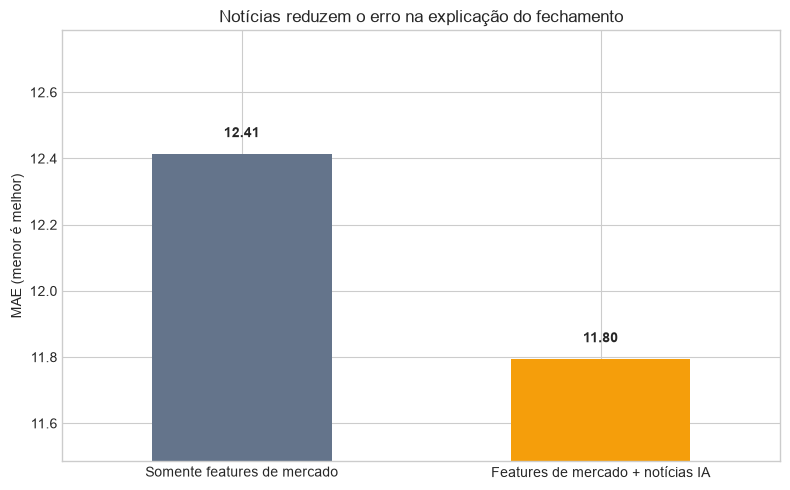

In [ ]:
plot_order = ['Somente features de mercado', 'Features de mercado + notícias IA']
ax = summary.loc[plot_order, 'mae'].plot.bar(figsize=(8, 5), color=['#64748b', '#f59e0b'], rot=0)

# Trunca o eixo Y próximo ao menor valor para a diferença visual
min_val = summary.loc[plot_order, 'mae'].min()
max_val = summary.loc[plot_order, 'mae'].max()
diff = max_val - min_val

# Define a base do eixo Y bem próxima do valor mínimo (ex: 80% do menor valor ou min_val - diff)
ax.set_ylim(min_val - diff * 0.5, max_val + diff * 0.6)

ax.set(xlabel='', ylabel='MAE (menor é melhor)', title='Notícias reduzem o erro na explicação do fechamento')

for index, value in enumerate(summary.loc[plot_order, 'mae']):
    # Offset reduzido proporcionalmente ao novo intervalo de Y
    ax.text(index, value + (diff * 0.08), f'{value:.2f}', ha='center', fontweight='bold')

print(f'Melhora no MAE com notícias : {(baseline_mae - news_mae) / baseline_mae:+.1%}')
print(f'Melhora no RMSE com notícias: {(baseline_rmse - news_rmse) / baseline_rmse:+.1%}')

plt.tight_layout()
plt.show()


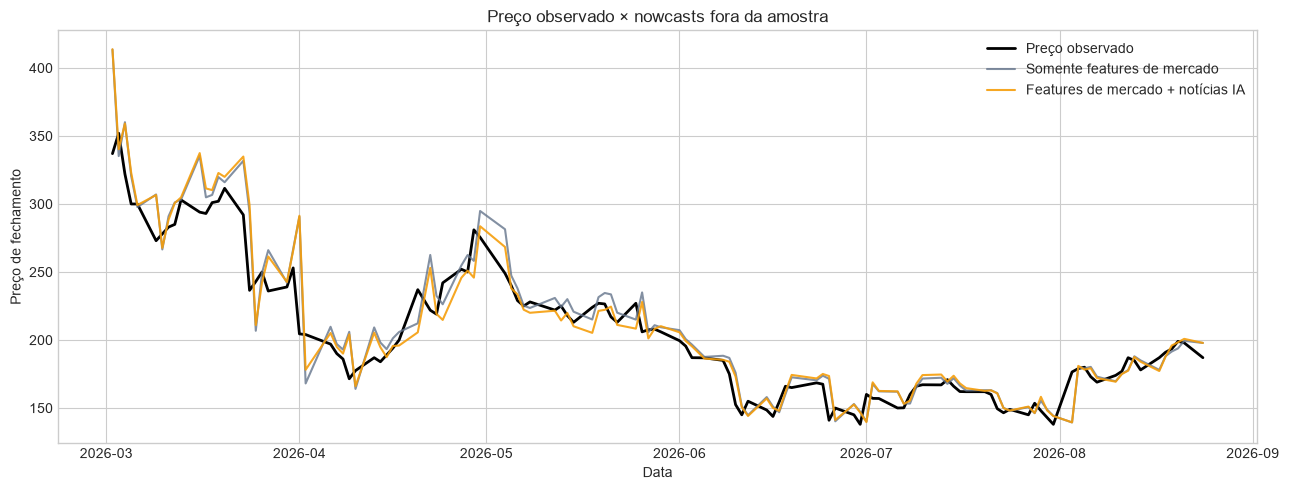

In [62]:
selected = predictions[predictions['model'].isin(['Somente features de mercado', 'Features de mercado + notícias IA'])]
wide = selected.pivot(index='date', columns='model', values='predicted')
actual = selected.drop_duplicates('date').set_index('date')['actual']
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(actual.index, actual, color='black', linewidth=2, label='Preço observado')
ax.plot(wide.index, wide['Somente features de mercado'], color='#64748b', alpha=.8, label='Somente features de mercado')
ax.plot(wide.index, wide['Features de mercado + notícias IA'], color='#f59e0b', alpha=.9, label='Features de mercado + notícias IA')
ax.set(title='Preço observado × nowcasts fora da amostra', xlabel='Data', ylabel='Preço de fechamento')
ax.legend(); plt.tight_layout(); plt.show()


## Conclusão do teste 2

Ao incluir notícias, o MAE cai de **12,41 para 11,80**, uma melhora de aprox **5,0%**.

O resultado sugere que o sinal textual explica uma parcela adicional do fechamento do dia.